In [21]:
from sympy import Function, Symbol, symbols, simplify, Eq, Symbol, latex, pprint, collect, expand
from sympy import init_printing
from IPython.display import display, Math

init_printing(use_latex=True)

In [22]:
import re
from IPython.display import display, Math

def color_terms(latex_str):
    latex_str = re.sub(
        r'(\\phi_\{REF\}\{\\left\(.+?\\right\)\})',
        r'{\\color{purple} \1}',
        latex_str
    )
    # Color all q_i(t) terms orange
    latex_str = re.sub(
        r'(q_\{([1])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{red} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(q_\{([2])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{orange} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(q_\{([3])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{yellow} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([A])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{Cyan} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([B])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{Aquamarine} \1{\\left(\3\\right)}}',
        latex_str
    )
    latex_str = re.sub(
        r'(\\epsilon_\{([C])\})\{\\left\((.+?)\\right\)\}',
        r'{\\color{SpringGreen} \1{\\left(\3\\right)}}',
        latex_str
    )
    return latex_str

In [23]:
# ── time variable ─────────────────────────────────────────────────────────────
t = Symbol('t')

# ── delay parameters ──────────────────────────────────────────────────────────
tau12, tau21, tau13, tau31, tau23, tau32 = symbols(
    r'\tau_{12} \tau_{21} \tau_{13} \tau_{31} \tau_{23} \tau_{32}',
    real=True, positive=True
)

# ── laser angular frequencies (physical + measurement offsets) ────────────────
omega1, omega2, omega3 = symbols(r'\omega_1 \omega_2 \omega_3', real=True)
omega1m, omega2m, omega3m = symbols(r'\omega_1^m \omega_2^m \omega_3^m', real=True)

For now, we assume frequencies to be constant in time. Hartwig et. al. did a bit of analysis how this affects the clock noise removal.

In [24]:
# ── abstract time-dependent functions ─────────────────────────────────────────
phi1  = Function(r'\phi_1')   # laser phase noise, s/c 1
phi2  = Function(r'\phi_2')
phi3  = Function(r'\phi_3')
phiREF  = Function(r'\phi_{REF}')

epsilonA = Function(r'\epsilon_A')  # clock noise, s/c 1 (master)
epsilonB = Function(r'\epsilon_B')  # clock noise, s/c 2
epsilonC = Function(r'\epsilon_C')  # clock noise, s/c 3

omegaREFA, omegaREFB, omegaREFC = symbols(r'\omega^{REF}_A \omega^{REF}_B \omega^{REF}_C', real=True)

q1 = Function('q_1')
q2 = Function('q_2')
q3 = Function('q_3')


N1_1 = Function('N_{1_1}') # measured on board 1 coming from laser 1
N2_2 = Function('N_{2_2}')
N3_3 = Function('N_{3_3}')

N1_2 = Function('N_{1_2}')
N1_3 = Function('N_{1_3}')
N2_1 = Function('N_{2_1}')
N2_3 = Function('N_{2_3}')
N3_1 = Function('N_{3_1}')
N3_2 = Function('N_{3_2}')


n1_1 = Function('n_{1_1}') # measured on board 1 coming from laser 1
n2_2 = Function('n_{2_2}')
n3_3 = Function('n_{3_3}')

n1_2 = Function('n_{1_2}')
n1_3 = Function('n _{1_3}')
n2_1 = Function('n_{2_1}')
n2_3 = Function('n_{2_3}')
n3_1 = Function('n_{3_1}')
n3_2 = Function('n_{3_2}')


N1_m = Function('P_{1}^{m}')
N2_m = Function('P_{2}^{m}')
N3_m = Function('P_{3}^{m}')

In [25]:
def D(expr, tau):
    return expr.subs(t, t - tau)

For the clock jitters, $\epsilon$ variables are used for the delay line boards. The $q$ variables are for the Mokus and in reference to the global time.

In [ ]:
# Map spacecraft index → (phi, q, omega, omega_m, clock_epsilon)
sc = {
    1: (phi1, q1, omega1, omega1m, epsilonA, omegaREFA, N1_m),
    2: (phi2, q2, omega2, omega2m, epsilonB, omegaREFB, N2_m),
    3: (phi3, q3, omega3, omega3m, epsilonC, omegaREFC, N3_m),
}

tau = {
    (1,2): tau12, (2,1): tau21,
    (1,3): tau13, (3,1): tau31,
    (2,3): tau23, (3,2): tau32,
}

N = {
    (1,2): (N1_1, N1_2, n1_1, n1_2), (1,3): (N1_1, N1_3, n1_1, n1_3),
    (2,1): (N2_1, N2_2, n2_1, n2_2), (2,3): (N2_2, N2_3, n2_2, n2_3),
    (3,1): (N3_1, N3_3, n3_1, n3_2), (3,2): (N3_3, N3_2, n3_3, n3_2)
}

eta    = {}
etaSB  = {}
REF  = {}
r = {}
r_m = {}

include_phi = True 
include_clock_noise = True
include_board_jitter = True   
include_REF_laser = False
include_optical_noise = False
# Reminder, what H&B call modulation noise, is actually timing jitter added to the modulation signal in the synthesis of the modulating signal. 
# This is something we may or may not experience, either way, this is different for us. This modulation noise here is literally the phase noise added by the modulator itself
include_modulation_noise = False  

for (i, j) in tau:
    phi_i, q_i, om_i, omm_i, eps_i, omegaREFi, N_i_m = sc[i]
    phi_j, q_j, om_j, omm_j, eps_j, omegaREFj, N_j_m = sc[j]
    t_ij = tau[(i, j)]
    Nij, Nji, nij, nji = N[(i,j)]

    phi_terms = (D(phi_j(t)-int(include_REF_laser)*phiREF(t), t_ij) - (phi_i(t)-int(include_REF_laser)*phiREF(t))) if include_phi else 0

    clock_terms_C = (- (om_j - om_i) * q_i(t)) if include_clock_noise else 0
    clock_terms_SB = (- (om_j - om_i + omm_j - omm_i) * q_i(t) - omm_i * q_i(t) + omm_j * D(q_j(t), t_ij)) if include_clock_noise else 0
    
    board_terms_c = (om_j * (eps_i(t) - D(eps_i(t), t_ij))) if include_board_jitter else 0
    board_terms_SB = ((om_j + omm_j) * (eps_i(t) - D(eps_i(t), t_ij))) if include_board_jitter else 0
    
    optical_terms = (Nij(t) - D(Nji(t), t_ij)) if include_optical_noise else 0
    optical_terms_SB = (nij(t) - D(nji(t), t_ij)) if include_optical_noise else 0

    eta[(i,j)] = (phi_terms + clock_terms_C + board_terms_c + optical_terms)

    etaSB[(i,j)] = collect(expand(phi_terms + clock_terms_SB + board_terms_SB + optical_terms_SB + int(include_modulation_noise) * (N_i_m(t) - D(N_j_m(t), t_ij))), [q_i(t), q_j(t)])

    r[(i,j)] = simplify(-(eta[(i,j)] - etaSB[(i,j)]) / omm_j)


    #phi_terms2 = (phi_j(t)-int(include_REF_laser)*phiREF(t) - (phi_i(t)-int(include_REF_laser)*phiREF(t))) if include_phi else 0
    #r_m[(i,j)] = collect(expand(phi_terms2), 
    #                     [q_i(t), q_j(t)])

    REF[(i,j)] = ( - int(include_clock_noise)*q_j(t) + int(include_board_jitter) * eps_i(t) ) # REF measured by the other PM, missing omegaREFi  *

The $\epsilon(t)$ terms originate from clock noise on the delay line boards which we will use three of. So we have A, B and C. Each corresponds to one spacecraft so the board A is where we apply delays 2 $\rightarrow$ 1 and 3 $\rightarrow$ 1. The $q(t)$ terms come from the Mokus. These are LISA-like, as in LISA will see similat clock noise coupling from the PM. All clock terms are given w.r.t the global clock, which we won't really ever know.

In [27]:
if True:
    for (i, j) in tau:
        display(Math(r'\eta_{' + str(i) + str(j) + '} = ' + color_terms(latex(eta[(i,j)]))))
        display(Math(r'\eta_{' + str(i) + str(j) + '}^{SB} = ' + color_terms(latex(etaSB[(i,j)]))))
        display(Math(r'\frac{r_{' + str(i) + str(j) + r'}}{\omega_{' + str(j) + '}^m} = ' + color_terms(latex(r[(i,j)]))))
        display(Math(r'\frac{REF_{' + str(i) + str(j) + r'}}{ \omega_{' + str(j) + '}^m} = ' + color_terms(latex(REF[(i,j)]))))
        #display(Math(r'\frac{r^{\text{m}}_{' + str(i) + str(j) + r'}}{\omega_{' + str(j) + '}^m} = ' + color_terms(latex(r_m[(i,j)]))))
        print("------------------------------------------------------")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------


We actually look at first generation TDI here. I do not know how to properly cancel out the timechaning delays with symbolic calculations.

In [28]:
def P12(expr): return expr - D(expr, tau13 + tau31)
def P21(expr): return D(expr, tau12) - D(expr, tau12 + tau13 + tau31)
def P13(expr): return -(expr - D(expr, tau12 + tau21))
def P31(expr): return -(D(expr, tau13) - D(expr, tau13 + tau12 + tau21))

# X1
X1 = collect(expand(P13(eta[(1,3)] + D(eta[(3,1)], tau13))+ P12(eta[(1,2)] + D(eta[(2,1)], tau12))), [q1(t), q2(t), q3(t), epsilonA(t), epsilonB(t), epsilonC(t)])

In [29]:
display(Math(r'X_1 = ' + color_terms(latex(X1)))) 

<IPython.core.display.Math object>

In [30]:
R = {}

R[(1,2)] = -(r[(1,3)] + D(r[(3,1)], tau13))

R[(1,3)] = r[(1,2)] + D(r[(2,1)], tau12)

R[(2,1)] = (r[(1,2)]
             - r[(1,3)]
             - D(r[(3,1)], tau13)
             - D(r[(1,2)], tau13 + tau31))

R[(3,1)] = (-r[(1,3)]
              + r[(1,2)]
              + D(r[(2,1)], tau12)
              + D(r[(1,3)], tau12 + tau21))

R[(2,3)] = 0
R[(3,2)] = 0

In [31]:
a = {
    (1,2): omega1 - omega2,
    (2,1): omega2 - omega1,
    (1,3): omega1 - omega3,
    (3,1): omega3 - omega1,
    (2,3): omega2 - omega3,
    (3,2): omega3 - omega2,
}

# clockwise triplets I+_3
triplets = [(1,2,3), (2,3,1), (3,1,2)]

correction = 0
for (i, j, k) in triplets:
    correction -= (
        - a[(i,j)] * R[(i,j)]
        - a[(i,k)] * R[(i,k)]
    )

X1c = simplify(X1 - correction) # Added a minus here bc the original r calc was flipped, which i now fixed, but didnt change in the correcting variables

In [32]:
print("The X1 expression is:")
display(Math(r'X_1 = ' + color_terms(latex(X1))))
#print("The clock-jitter correction term is:")
#display(Math(r'X_1 = ' + color_terms(latex(simplify(-correction)))))
print("The corrected X1 expression is:")
display(Math(r'X_1 = ' + color_terms(latex(X1c))))

The X1 expression is:


<IPython.core.display.Math object>

The corrected X1 expression is:


<IPython.core.display.Math object>

In [33]:
REF_AB= REF[(1,3)] - REF[(2,3)]
REF_AC= REF[(3,2)] - REF[(1,2)]
REF_CB= REF[(2,1)] - REF[(3,1)]

display(Math(r'REF_{AB} = ' + color_terms(latex(REF_AB))))
display(Math(r'REF_{AC} = ' + color_terms(latex(REF_AC))))
display(Math(r'REF_{CB} = ' + color_terms(latex(REF_CB))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [34]:
Corr1 = omega1*(D(REF_AB, tau12) - D(REF_AB, tau12 + tau21) - D(REF_AB, tau12 + tau13 + tau31))
Corr2 = omega1*(D(REF_AC, tau13) - D(REF_AC, tau13 + tau31) - D(REF_AC, tau12 + tau13 + tau21))
Corr3 = -omega1*(D(REF_CB, tau12 + tau13 + tau21 + tau31))
display(Math(r'X_1 = ' + color_terms(latex(simplify(X1c + Corr1 + Corr2 + Corr3)))))

<IPython.core.display.Math object>

To considere real residuals: ranging error, timevarying beatnote frequencies.

Lets move it to frequency domain?

In [35]:
import numpy as np

In [36]:
from sympy import exp, I, expand, Symbol, lambdify
from sympy import Function as SympyFunction
import numpy as np

omega_sym = Symbol('omega', real=True, positive=True)

# Master list of ALL noise Function classes that can appear in any expression.
# Used by get_transfer_function to zero out everything except the target noise.
master_noise_funcs = [
    phi1, phi2, phi3,
    q1, q2, q3,
    epsilonA, epsilonB, epsilonC,
    N1_m, N2_m, N3_m,
    N1_1, N1_2, N1_3, N2_1, N2_2, N2_3, N3_1, N3_2, N3_3,
    n1_1, n1_2, n2_1, n2_2, n3_1, n3_2, n3_3,
]

def build_eta_for_noise(noise_type):
    eta = {}
    for (i, j) in tau:
        phi_i, q_i, om_i, omm_i, eps_i, _, N_i_m = sc[i]
        phi_j, q_j, om_j, omm_j, eps_j, _, N_j_m = sc[j]
        t_ij = tau[(i, j)]
        Nij, Nji, nij, nji = N[(i, j)]
        if noise_type == 'phi':
            eta[(i,j)] = expand(D(phi_j(t), t_ij) - phi_i(t))
        elif noise_type == 'clock':
            eta[(i,j)] = expand(-(om_j - om_i) * q_i(t))
        elif noise_type == 'board':
            eta[(i,j)] = expand(om_j * (eps_i(t) - D(eps_i(t), t_ij)))
        elif noise_type == 'optical':
            eta[(i,j)] = expand(Nij(t) - D(Nji(t), t_ij))
        elif noise_type == 'modulation':
            eta[(i,j)] = expand(N_i_m(t) - D(N_j_m(t), t_ij))
        else:
            eta[(i,j)] = 0
    return eta

def build_tdi_from_eta(eta, tdi_name='X1'):
    if tdi_name == 'X1':
        def P12(e): return e - D(e, tau13 + tau31)
        def P13(e): return -(e - D(e, tau12 + tau21))
        return expand(P13(eta[(1,3)] + D(eta[(3,1)], tau13)) + P12(eta[(1,2)] + D(eta[(2,1)], tau12)))
    elif tdi_name == 'alpha1':
        return expand(eta[(1,2)] + D(eta[(2,3)], tau12) + D(eta[(3,1)], tau12 + tau23)
                    - eta[(1,3)] - D(eta[(3,2)], tau13) - D(eta[(2,1)], tau13 + tau32))
    else:
        raise ValueError(f"Unknown TDI '{tdi_name}'")

def get_transfer_function(tdi_expr, noise_func):
    """Extract H(omega) for noise_func. Zeros out ALL other noise functions
    in master_noise_funcs so stray terms (e.g. epsilon in X1c) don't survive."""
    zero_subs = {}
    for fn in master_noise_funcs:
        if fn == noise_func:
            continue
        for inst in tdi_expr.atoms(SympyFunction):
            if inst.func == fn:
                zero_subs[inst] = 0
    expr2 = tdi_expr.subs(zero_subs)
    phase_subs = {inst: exp(-I * omega_sym * (t - inst.args[0]))
                  for inst in expr2.atoms(SympyFunction) if inst.func == noise_func}
    return expand(expr2.subs(phase_subs))

def _eval_H(H_num, omegas):
    """lambdify returns a scalar when H is constant; broadcast to array."""
    return np.ones(len(omegas), dtype=complex) * H_num(omegas)

print("Cell 1 ready.")


Cell 1 ready.


In [37]:
from sympy import collect, latex
from IPython.display import display, Math

noise_to_check = 'clock'   # change to 'optical', 'clock', 'modulation', 'phi'
fn_list_map = {
    'optical':    [N1_1,N1_2,N1_3,N2_1,N2_2,N2_3,N3_1,N3_2,N3_3],
    'modulation': [N1_m, N2_m, N3_m],
    'clock':      [q1, q2, q3],
    'board':      [epsilonA, epsilonB, epsilonC],
    'phi':        [phi1, phi2, phi3],
}

eta_k  = build_eta_for_noise(noise_to_check)
X1_k   = build_tdi_from_eta(eta_k, 'X1')

print(f"Noise type: {noise_to_check}")
print(f"TDI combination: X1")
print()

for fn in fn_list_map[noise_to_check]:
    H = get_transfer_function(X1_k, fn)
    display(Math(f'H_{{\\mathrm{{{fn.name}}}}}(\\omega) = ' + latex(H)))


Noise type: clock
TDI combination: X1



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Heterodyne frequencies used:
  nu1 = 15.0 MHz
  nu2 = nu1 - O12 = 6.9 MHz
  nu3 = nu1 - O13 = 13.6 MHz


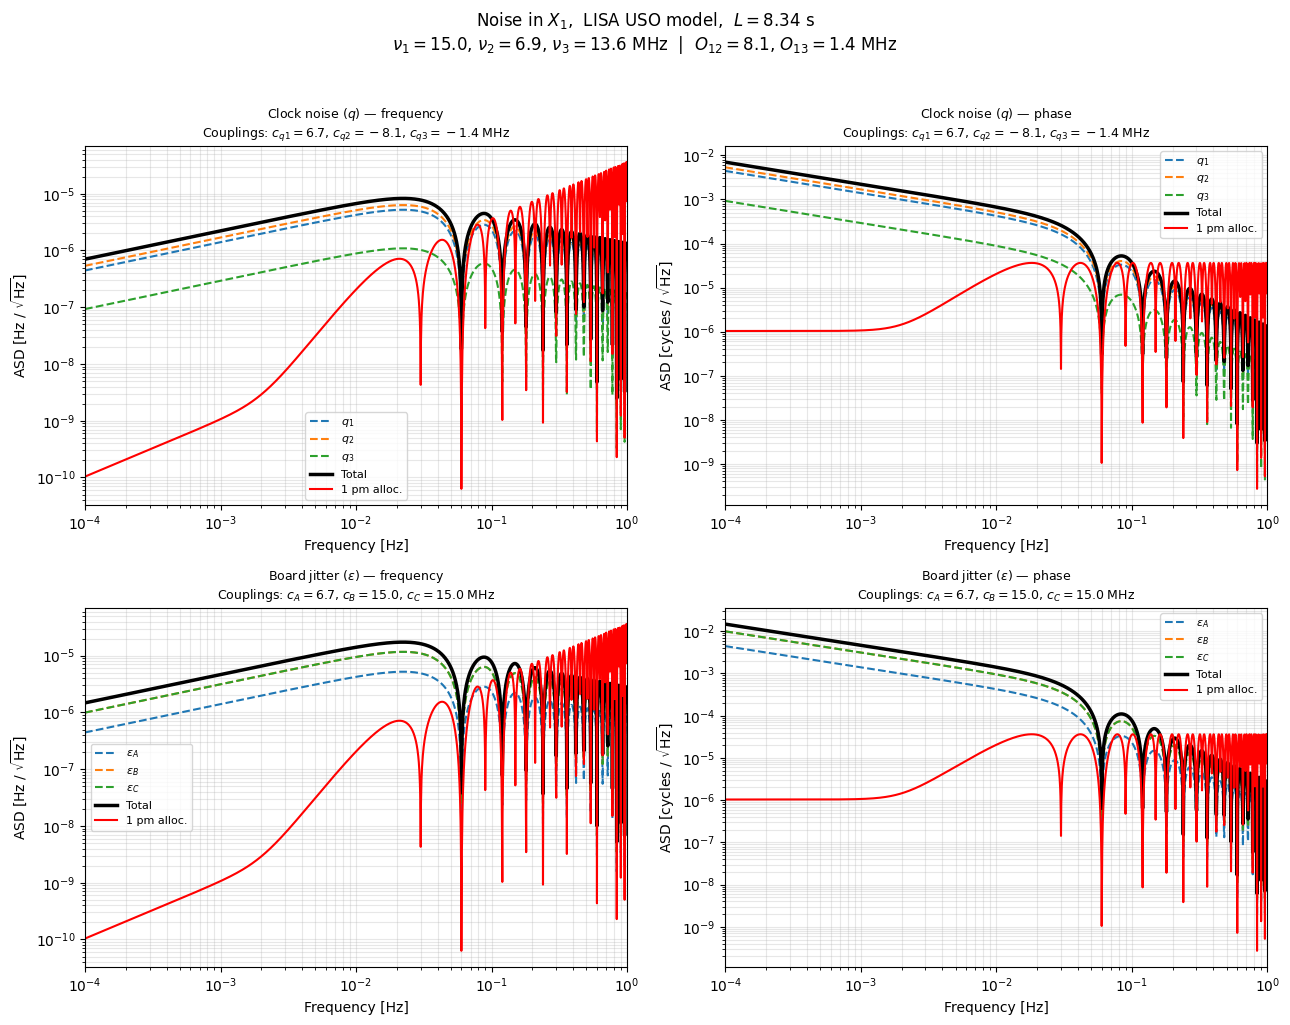

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
c            = 299792458.0
lambda_laser = 1064e-9
L            = 2.5e9 / c

freqs = np.logspace(-4, 0, 2000)
omega = 2 * np.pi * freqs

def ph(tau):
    return np.exp(-1j * omega * tau)

# ── Heterodyne frequencies (omega_j in your notebook, all in Hz) ──────────────
# These are the beatnote/heterodyne frequencies, NOT the optical carrier.
# omega_1 - omega_2 = O12, omega_1 - omega_3 = O13 etc.
O12 =  8.1e6    # Hz
O21 = -9.5e6
O13 =  1.4e6
O31 = 10.3e6

# nu_j values (heterodyne freqs per spacecraft, relative to SC1)
# nu1 = nu0_het, nu2 = nu0_het - O12, nu3 = nu0_het - O13
# For coupling differences, nu0_het cancels just like the optical carrier would.
# We only need the offsets. Choose a reference heterodyne freq for SC1:
nu1 = 15e6      # Hz — SC1 heterodyne frequency (adjust to your setup)
nu2 = nu1 - O12
nu3 = nu1 - O13

print(f"Heterodyne frequencies used:")
print(f"  nu1 = {nu1/1e6:.1f} MHz")
print(f"  nu2 = nu1 - O12 = {nu2/1e6:.1f} MHz")
print(f"  nu3 = nu1 - O13 = {nu3/1e6:.1f} MHz")

# ── USO PSD ───────────────────────────────────────────────────────────────────
S_q = 4e-27 / freqs

# ── 1 pm allocation ───────────────────────────────────────────────────────────
Sx_alloc     = (64 * omega**2 * np.sin(omega*L)**2 * np.sin(2*omega*L)**2
                * (1e-12 / lambda_laser)**2 * (1 + (2e-3 / freqs)**4))
asd_alloc_freq  = np.sqrt(Sx_alloc)
asd_alloc_phase = asd_alloc_freq / freqs

# ══════════════════════════════════════════════════════════════════════════════
# Clock noise (q)
# eta_clock_{ij} = -(omega_j - omega_i) * q_i  -> coupling = nu_i - nu_j
# ══════════════════════════════════════════════════════════════════════════════
c_q1 =  nu1 - nu2    # = O12 =  8.1 MHz
c_q2 =  nu2 - nu1    # = -O12 = -8.1 MHz  (q2 in eta_21)
c_q3 =  nu3 - nu1    # = -O13 = -1.4 MHz  (q3 in eta_31)

H_q1 = (c_q1 - c_q3) * (1 - ph(2*L))          # residual after X1 TDI combination
H_q2 = c_q2 * ph(L) * (1 - ph(2*L))
H_q3 = c_q3 * ph(L) * (1 - ph(2*L))

# Wait — recheck H_q1: from eta_12 (coeff c_q1 = nu1-nu2) and eta_13 (coeff nu1-nu3)
# after TDI X1 the residual is (nu1-nu2) - (nu1-nu3) = nu3-nu2 = O12-O13
c_q1_eff = (nu1-nu2) - (nu1-nu3)   # = nu3 - nu2 = O12 - O13

H_q1 = c_q1_eff * (1 - ph(2*L))
H_q2 = c_q2     * ph(L) * (1 - ph(2*L))
H_q3 = c_q3     * ph(L) * (1 - ph(2*L))

asd_q1_freq  = np.sqrt(np.abs(H_q1)**2 * S_q)
asd_q2_freq  = np.sqrt(np.abs(H_q2)**2 * S_q)
asd_q3_freq  = np.sqrt(np.abs(H_q3)**2 * S_q)
asd_clk_freq = np.sqrt((np.abs(H_q1)**2 + np.abs(H_q2)**2 + np.abs(H_q3)**2) * S_q)

asd_q1_phase  = asd_q1_freq  / freqs
asd_q2_phase  = asd_q2_freq  / freqs
asd_q3_phase  = asd_q3_freq  / freqs
asd_clk_phase = asd_clk_freq / freqs

# ══════════════════════════════════════════════════════════════════════════════
# Board jitter (epsilon)
# eta_board_{ij} = omega_j * (eps_i - D(eps_i, tau_ij))
# omega_j here is the heterodyne freq of SC j (same as clock noise)
# eps_A (SC1 board): in eta_12 (coeff nu2) and eta_13 (coeff nu3)
#   after X1 TDI: nu0 cancels -> residual = nu3 - nu2 = O12 - O13
# eps_B (SC2 board): only in eta_21 (coeff nu1)
# eps_C (SC3 board): only in eta_31 (coeff nu1)
# ══════════════════════════════════════════════════════════════════════════════
c_A = nu3 - nu2    # = O12 - O13 =  6.7 MHz
c_B = nu1          # = 15.0 MHz
c_C = nu1          # = 15.0 MHz

H_A = c_A * (1 - ph(2*L))
H_B = c_B * ph(L) * (1 - ph(2*L))
H_C = c_C * ph(L) * (1 - ph(2*L))

asd_A_freq     = np.sqrt(np.abs(H_A)**2 * S_q)
asd_B_freq     = np.sqrt(np.abs(H_B)**2 * S_q)
asd_C_freq     = np.sqrt(np.abs(H_C)**2 * S_q)
asd_board_freq = np.sqrt((np.abs(H_A)**2 + np.abs(H_B)**2 + np.abs(H_C)**2) * S_q)

asd_A_phase     = asd_A_freq     / freqs
asd_B_phase     = asd_B_freq     / freqs
asd_C_phase     = asd_C_freq     / freqs
asd_board_phase = asd_board_freq / freqs

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

freq_str  = (f"$\\nu_1={nu1/1e6:.1f}$, $\\nu_2={nu2/1e6:.1f}$, $\\nu_3={nu3/1e6:.1f}$ MHz  |  "
             f"$O_{{12}}={O12/1e6:.1f}$, $O_{{13}}={O13/1e6:.1f}$ MHz")
clock_str = (f"Couplings: $c_{{q1}}={c_q1_eff/1e6:.1f}$, $c_{{q2}}={c_q2/1e6:.1f}$, "
             f"$c_{{q3}}={c_q3/1e6:.1f}$ MHz")
board_str = (f"Couplings: $c_A={c_A/1e6:.1f}$, $c_B={c_B/1e6:.1f}$, "
             f"$c_C={c_C/1e6:.1f}$ MHz")

# ── Clock, frequency noise ────────────────────────────────────────────────────
ax = axes[0, 0]
ax.loglog(freqs, asd_q1_freq,    lw=1.5, ls='--', label=r'$q_1$')
ax.loglog(freqs, asd_q2_freq,    lw=1.5, ls='--', label=r'$q_2$')
ax.loglog(freqs, asd_q3_freq,    lw=1.5, ls='--', label=r'$q_3$')
ax.loglog(freqs, asd_clk_freq,   lw=2.5, color='k', label='Total')
ax.loglog(freqs, asd_alloc_freq, lw=1.5, color='red', label='1 pm alloc.')
ax.set_title(f'Clock noise ($q$) — frequency\n{clock_str}', fontsize=9)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [Hz / $\sqrt{\mathrm{Hz}}$]')
ax.set_xlim([freqs[0], freqs[-1]])
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# ── Clock, phase noise ────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.loglog(freqs, asd_q1_phase,    lw=1.5, ls='--', label=r'$q_1$')
ax.loglog(freqs, asd_q2_phase,    lw=1.5, ls='--', label=r'$q_2$')
ax.loglog(freqs, asd_q3_phase,    lw=1.5, ls='--', label=r'$q_3$')
ax.loglog(freqs, asd_clk_phase,   lw=2.5, color='k', label='Total')
ax.loglog(freqs, asd_alloc_phase, lw=1.5, color='red', label='1 pm alloc.')
ax.set_title(f'Clock noise ($q$) — phase\n{clock_str}', fontsize=9)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [cycles / $\sqrt{\mathrm{Hz}}$]')
ax.set_xlim([freqs[0], freqs[-1]])
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# ── Board, frequency noise ────────────────────────────────────────────────────
ax = axes[1, 0]
ax.loglog(freqs, asd_A_freq,     lw=1.5, ls='--', label=r'$\epsilon_A$')
ax.loglog(freqs, asd_B_freq,     lw=1.5, ls='--', label=r'$\epsilon_B$')
ax.loglog(freqs, asd_C_freq,     lw=1.5, ls='--', label=r'$\epsilon_C$')
ax.loglog(freqs, asd_board_freq, lw=2.5, color='k', label='Total')
ax.loglog(freqs, asd_alloc_freq, lw=1.5, color='red', label='1 pm alloc.')
ax.set_title(f'Board jitter ($\\epsilon$) — frequency\n{board_str}', fontsize=9)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [Hz / $\sqrt{\mathrm{Hz}}$]')
ax.set_xlim([freqs[0], freqs[-1]])
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# ── Board, phase noise ────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.loglog(freqs, asd_A_phase,     lw=1.5, ls='--', label=r'$\epsilon_A$')
ax.loglog(freqs, asd_B_phase,     lw=1.5, ls='--', label=r'$\epsilon_B$')
ax.loglog(freqs, asd_C_phase,     lw=1.5, ls='--', label=r'$\epsilon_C$')
ax.loglog(freqs, asd_board_phase, lw=2.5, color='k', label='Total')
ax.loglog(freqs, asd_alloc_phase, lw=1.5, color='red', label='1 pm alloc.')
ax.set_title(f'Board jitter ($\\epsilon$) — phase\n{board_str}', fontsize=9)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [cycles / $\sqrt{\mathrm{Hz}}$]')
ax.set_xlim([freqs[0], freqs[-1]])
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

plt.suptitle(f'Noise in $X_1$,  LISA USO model,  $L={L:.2f}$ s\n{freq_str}', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Get symbolic H from your existing pipeline
H_q1_sym = get_transfer_function(X1_k, q1)

# 2. Substitute numerical values for all parameters
num_subs = {
    omega1:  2*np.pi * nu1,
    omega2:  2*np.pi * nu2,
    omega3:  2*np.pi * nu3,
    tau12: L, tau21: L,
    tau13: L, tau31: L,
    tau23: L, tau32: L,
}
H_q1_num = lambdify(omega_sym, H_q1_sym.subs(num_subs), modules='numpy')

# 3. Evaluate over frequency array
freqs = np.logspace(-4, 0, 2000)
omegas = 2*np.pi*freqs
H_vals = np.ones(len(omegas), dtype=complex) * H_q1_num(omegas)

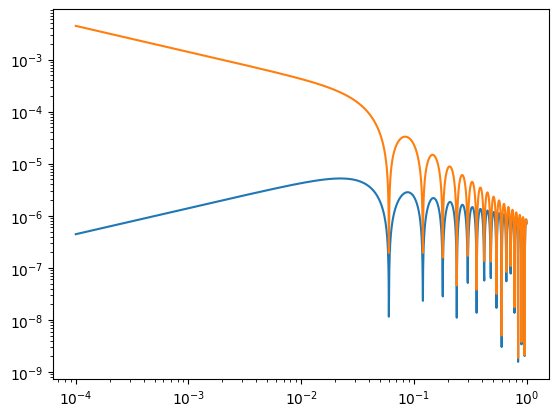

In [ ]:
S = np.abs(H_vals)**2 * S_q          # wrong — H in rad/s
S = np.abs(H_vals / (2*np.pi))**2 * S_q   # correct — H in Hz
asd_freq  = np.sqrt(S)          # Hz/sqrt(Hz)
asd_phase = asd_freq / freqs    # cycles/sqrt(Hz)

plt.loglog(freqs, asd_freq)
plt.loglog(freqs, asd_phase)

Let's try with Sagnac

In [39]:
# Sagnac alpha_1 centered on SC1
# alpha_1 = eta12 + D12*eta23 + D123*eta31 - eta13 - D13*eta32 - D132*eta21

def P12_sagnac(expr): return expr
def P23_sagnac(expr): return D(expr, tau12)
def P31_sagnac(expr): return D(expr, tau12 + tau23)
def P13_sagnac(expr): return -expr
def P32_sagnac(expr): return -D(expr, tau13)
def P21_sagnac(expr): return -D(expr, tau13 + tau32)

R_sagnac = {}
R_sagnac[(1,2)] = 0
R_sagnac[(2,3)] = r[(1,2)]
R_sagnac[(3,1)] = r[(1,2)] + D(r[(2,3)], tau12)
R_sagnac[(1,3)] = 0
R_sagnac[(3,2)] = -r[(1,3)]
R_sagnac[(2,1)] = -(r[(1,3)] + D(r[(3,2)], tau13))

In [40]:
a = {
    (1,2): omega1 - omega2,
    (2,1): omega2 - omega1,
    (1,3): omega1 - omega3,
    (3,1): omega3 - omega1,
    (2,3): omega2 - omega3,
    (3,2): omega3 - omega2,
}

# clockwise triplets I+_3
triplets = [(1,2,3), (2,3,1), (3,1,2)]

correction = 0
for (i, j, k) in triplets:
    correction -= (
        - a[(i,j)] * R_sagnac[(i,j)]
        - a[(i,k)] * R_sagnac[(i,k)]
    )

alpha1 = collect(expand(
      P12_sagnac(eta[(1,2)])
    + P23_sagnac(eta[(2,3)])
    + P31_sagnac(eta[(3,1)])
    + P13_sagnac(eta[(1,3)])
    + P32_sagnac(eta[(3,2)])
    + P21_sagnac(eta[(2,1)])
), [q1(t), q2(t), q3(t), epsilonA(t), epsilonB(t), epsilonC(t)])


alpha1c = simplify(alpha1 - correction)

print("The alpha_1 expression is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1))))  
print("The corrected alpha_1 expression is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1c))))

The alpha_1 expression is:


<IPython.core.display.Math object>

The corrected alpha_1 expression is:


<IPython.core.display.Math object>

In [41]:
display(latex(alpha1))

'- \\omega_{1} \\epsilon_{B}{\\left(- \\tau_{13} - \\tau_{32} + t \\right)} + \\omega_{1} \\epsilon_{B}{\\left(- \\tau_{13} - \\tau_{21} - \\tau_{32} + t \\right)} + \\omega_{1} \\epsilon_{C}{\\left(- \\tau_{12} - \\tau_{23} + t \\right)} - \\omega_{1} \\epsilon_{C}{\\left(- \\tau_{12} - \\tau_{23} - \\tau_{31} + t \\right)} + \\omega_{1} q_{2}{\\left(- \\tau_{13} - \\tau_{32} + t \\right)} - \\omega_{1} q_{3}{\\left(- \\tau_{12} - \\tau_{23} + t \\right)} - \\omega_{2} \\epsilon_{A}{\\left(- \\tau_{12} + t \\right)} - \\omega_{2} \\epsilon_{C}{\\left(- \\tau_{13} + t \\right)} + \\omega_{2} \\epsilon_{C}{\\left(- \\tau_{13} - \\tau_{32} + t \\right)} + \\omega_{2} q_{2}{\\left(- \\tau_{12} + t \\right)} - \\omega_{2} q_{2}{\\left(- \\tau_{13} - \\tau_{32} + t \\right)} + \\omega_{2} q_{3}{\\left(- \\tau_{13} + t \\right)} + \\omega_{3} \\epsilon_{A}{\\left(- \\tau_{13} + t \\right)} + \\omega_{3} \\epsilon_{B}{\\left(- \\tau_{12} + t \\right)} - \\omega_{3} \\epsilon_{B}{\\left(- \\ta

In [42]:
CorrA_sagnac = omega1 * (D(REF_AC, tau13) + D(REF_AB, tau12))
CorrBC_sagnac = omega1 * (D(REF_CB, tau12+tau23) + D(REF_CB, tau13+tau32) - D(REF_CB, tau12 + tau23 + tau31))

alpha1_corrected = simplify(alpha1c + CorrA_sagnac + CorrBC_sagnac).subs({tau12:tau21, tau13: tau31, tau23: tau32})
print("The alpha_1 expression with only REF corrections is:")
display(Math(r'\alpha_1 = ' + color_terms(latex(alpha1_corrected))))

The alpha_1 expression with only REF corrections is:


<IPython.core.display.Math object>

Let's see if we can get rid of the board jitters before the TDI

cant